In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
print(sys.path)

['D:\\Program Files\\Python3.9.6\\python39.zip', 'D:\\Program Files\\Python3.9.6\\DLLs', 'D:\\Program Files\\Python3.9.6\\lib', 'D:\\Program Files\\Python3.9.6', 'd:\\git项目\\vs_evaluation\\venv', '', 'd:\\git项目\\vs_evaluation\\venv\\lib\\site-packages', 'd:\\git项目\\vs_evaluation\\venv\\lib\\site-packages\\win32', 'd:\\git项目\\vs_evaluation\\venv\\lib\\site-packages\\win32\\lib', 'd:\\git项目\\vs_evaluation\\venv\\lib\\site-packages\\Pythonwin', 'd:\\git项目\\vs_evaluation']


# 模拟（无测量误差）

In [6]:
from src.Lasso import LassoRegression as myLasso
from sklearn.linear_model import Lasso as skLasso
from src.vs_evaluate import selection_accuracy

# 生成一些示例数据
import numpy as np
np.random.seed(42)
X = np.random.rand(1000, 10)
beta = np.array([1.5, -2.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, -0.1, 0.0])
y = X @ beta + np.random.normal(0, 0.5, size=1000)

mylasso = myLasso(alpha=0.01, max_iter=1000, tol=1e-4)
sklasso = skLasso(alpha=0.01, fit_intercept=True, max_iter=1000, tol=1e-4)
mylasso.fit(X=X, y=y)
sklasso.fit(X=X, y=y)

# 评估变量选择结果
true_indices = [i for i in range(len(beta)) if beta[i] != 0]
mylasso_vs_indices = [i for i in range(len(mylasso.coef_)) if mylasso.coef_[i] != 0]
sklasso_vs_indices = [i for i in range(len(sklasso.coef_)) if sklasso.coef_[i] != 0]

print("真实系数：", beta)
print("My Lasso：", mylasso.coef_, mylasso.intercept_)
print("Sklearn Lasso：", sklasso.coef_, sklasso.intercept_)

print("真实变量索引：", true_indices)
print("My Lasso 变量选择结果（索引）：", mylasso_vs_indices)
print("Sklearn Lasso 变量选择结果（索引）：", sklasso_vs_indices)

print("My Lasso 变量选择结果评估：", selection_accuracy(true_indices, mylasso_vs_indices, len(beta)))
print("Sklearn Lasso 变量选择结果评估：", selection_accuracy(true_indices, sklasso_vs_indices, len(beta)))

真实系数： [ 1.5 -2.   0.   0.   0.2  0.   0.   0.  -0.1  0. ]
My Lasso： [ 1.27576244 -1.87072051  0.          0.          0.0234012   0.
 -0.00323166  0.          0.          0.        ] 0.09562055418431728
Sklearn Lasso： [ 1.27576244 -1.87072051 -0.          0.          0.0234012  -0.
 -0.00323166 -0.         -0.          0.        ] 0.0956205541843165
真实变量索引： [0, 1, 4, 8]
My Lasso 变量选择结果（索引）： [0, 1, 4, 6]
Sklearn Lasso 变量选择结果（索引）： [0, 1, 4, 6]
My Lasso 变量选择结果评估： {'TP': 3, 'FP': 1, 'FN': 1, 'TN': 5, 'Precision': 0.75, 'Recall': 0.75, 'F1': 0.75, 'Specificity': 0.8333333333333334, 'Hamming_Distance': np.float64(0.2), 'Accuracy': 0.8}
Sklearn Lasso 变量选择结果评估： {'TP': 3, 'FP': 1, 'FN': 1, 'TN': 5, 'Precision': 0.75, 'Recall': 0.75, 'F1': 0.75, 'Specificity': 0.8333333333333334, 'Hamming_Distance': np.float64(0.2), 'Accuracy': 0.8}


# 模拟（带测量误差）

In [5]:
np.random.seed(42)
X_error = X + np.random.normal(0, 0.4, size=X.shape)
y_error = X @ beta + np.random.normal(0, 0.5, size=1000)

mylasso_naive = myLasso(alpha=0.01, max_iter=1000, tol=1e-4)
sklasso_naive = skLasso(alpha=0.01, fit_intercept=True, max_iter=1000, tol=1e-4)
mylasso_naive.fit(X=X_error, y=y_error)
sklasso_naive.fit(X=X_error, y=y_error)

# 评估变量选择结果
true_indices = [i for i in range(len(beta)) if beta[i] != 0]
naive_mylasso_vs_indices = [i for i in range(len(mylasso_naive.coef_)) if mylasso_naive.coef_[i] != 0]
naive_sklasso_vs_indices = [i for i in range(len(sklasso_naive.coef_)) if sklasso_naive.coef_[i] != 0]

print("真实系数：", beta)
print("My Lasso：", mylasso_naive.coef_, mylasso_naive.intercept_)
print("Sklearn Lasso：", sklasso_naive.coef_, sklasso_naive.intercept_)

print("真实变量索引：", true_indices)
print("My Lasso 变量选择结果（索引）：", naive_mylasso_vs_indices)
print("Sklearn Lasso 变量选择结果（索引）：", naive_sklasso_vs_indices)

print("My Lasso 变量选择结果评估：", selection_accuracy(true_indices, naive_mylasso_vs_indices, len(beta)))
print("Sklearn Lasso 变量选择结果评估：", selection_accuracy(true_indices, naive_sklasso_vs_indices, len(beta)))

真实系数： [ 1.5 -2.   0.   0.   0.2  0.   0.   0.  -0.1  0. ]
My Lasso： [ 0.52295932 -0.62835845  0.          0.05173801  0.06979389  0.
  0.          0.01304983  0.          0.        ] -0.24687869673367108
Sklearn Lasso： [ 0.52295687 -0.62835738 -0.          0.05173814  0.06979386  0.
  0.          0.01304981  0.          0.        ] -0.2468780983654209
真实变量索引： [0, 1, 4, 8]
My Lasso 变量选择结果（索引）： [0, 1, 3, 4, 7]
Sklearn Lasso 变量选择结果（索引）： [0, 1, 3, 4, 7]
My Lasso 变量选择结果评估： {'TP': 3, 'FP': 2, 'FN': 1, 'TN': 4, 'Precision': 0.6, 'Recall': 0.75, 'F1': 0.6666666666666665, 'Specificity': 0.6666666666666666, 'Hamming_Distance': np.float64(0.3), 'Accuracy': 0.7}
Sklearn Lasso 变量选择结果评估： {'TP': 3, 'FP': 2, 'FN': 1, 'TN': 4, 'Precision': 0.6, 'Recall': 0.75, 'F1': 0.6666666666666665, 'Specificity': 0.6666666666666666, 'Hamming_Distance': np.float64(0.3), 'Accuracy': 0.7}


# 一种情况下

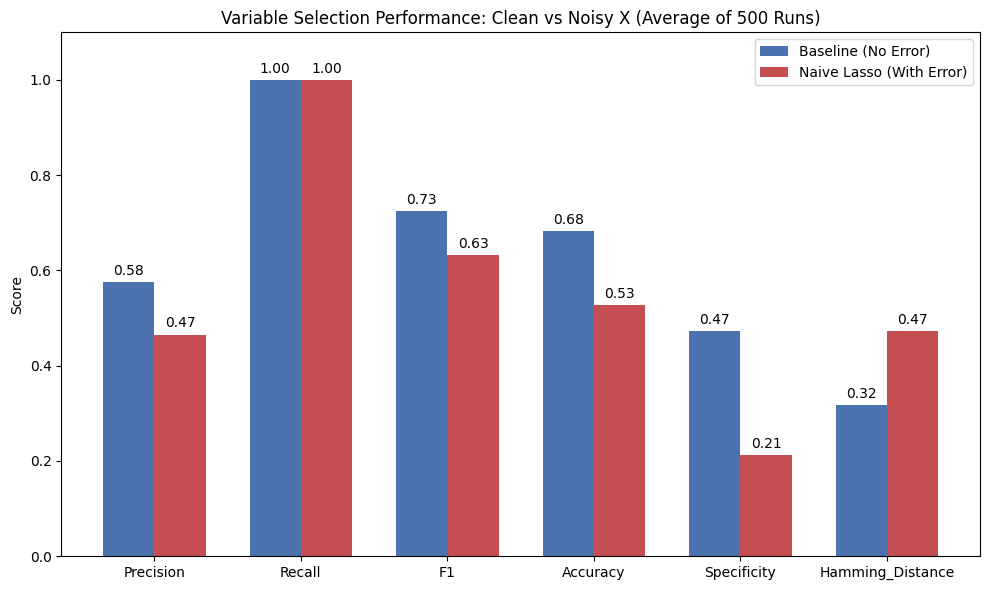

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from src.Lasso import LassoRegression as myLasso
from src.vs_evaluate import selection_accuracy

def run_simulation(n_simulations=500):
    # 用于存储评估结果的列表
    metrics_to_track = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
    
    # 初始化存储结构：{ 'Clean': {metric: []}, 'Noisy': {metric: []} }
    results = {
        'Clean': {m: [] for m in metrics_to_track},
        'Noisy': {m: [] for m in metrics_to_track}
    }

    for _ in range(n_simulations):
        # 1. 生成原始数据 (无误差)
        n_samples, n_features = 1000, 10
        X = np.random.randn(n_samples, n_features)
        beta = np.array([1.5, -2.0, 0, 0, 0.2, 0, 0, 0, -0.1, 0])
        y = X @ beta + np.random.normal(0, 0.5, size=n_samples)
        true_indices = [i for i, b in enumerate(beta) if b != 0]

        # 2. 生成带误差的数据
        X_error = X + np.random.normal(0, 0.4, size=X.shape)
        y_error = X @ beta + np.random.normal(0, 0.5, size=n_samples)

        # 3. 分别拟合模型
        # 情况 A: 无测量误差
        model_clean = myLasso(alpha=0.01)
        model_clean.fit(X, y)
        idx_clean = [i for i, c in enumerate(model_clean.coef_) if c != 0]
        acc_clean = selection_accuracy(true_indices, idx_clean, n_features)

        # 情况 B: 带测量误差
        model_noisy = myLasso(alpha=0.01)
        model_noisy.fit(X_error, y_error)
        idx_noisy = [i for i, c in enumerate(model_noisy.coef_) if c != 0]
        acc_noisy = selection_accuracy(true_indices, idx_noisy, n_features)

        # 4. 收集指标
        for m in metrics_to_track:
            results['Clean'][m].append(acc_clean[m])
            results['Noisy'][m].append(acc_noisy[m])

    # 5. 计算均值
    final_means = {
        'Clean': [np.mean(results['Clean'][m]) for m in metrics_to_track],
        'Noisy': [np.mean(results['Noisy'][m]) for m in metrics_to_track]
    }
    
    return metrics_to_track, final_means

# 执行模拟
metrics, means = run_simulation(500)

# --- 可视化部分 ---
x = np.arange(len(metrics))  # 指标位置
width = 0.35  # 柱状图宽度

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, means['Clean'], width, label='Baseline (No Error)', color='#4C72B0')
rects2 = ax.bar(x + width/2, means['Noisy'], width, label='Naive Lasso (With Error)', color='#C44E52')

# 添加标签和格式
ax.set_ylabel('Score')
ax.set_title(f'Variable Selection Performance: Clean vs Noisy X (Average of 500 Runs)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

# 在柱状图上标注数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3点纵向偏移
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# 不同测量误差大小的情况
+ 使用我的lasso代码，前 4 个是预设相关变量，参数设置为 1.5, -2.0, 0.2, -0.1，500 次模拟取评估指标的均值，随机种子 42（固定）
+ 测量误差强度从 0 到 5 变化共 40 个点（正在测试变化）
+ 样本量为 1000，正则化强度为 0.01，变量数量为 10（未测试变化）
+ 结果出来很快，1 分钟左右

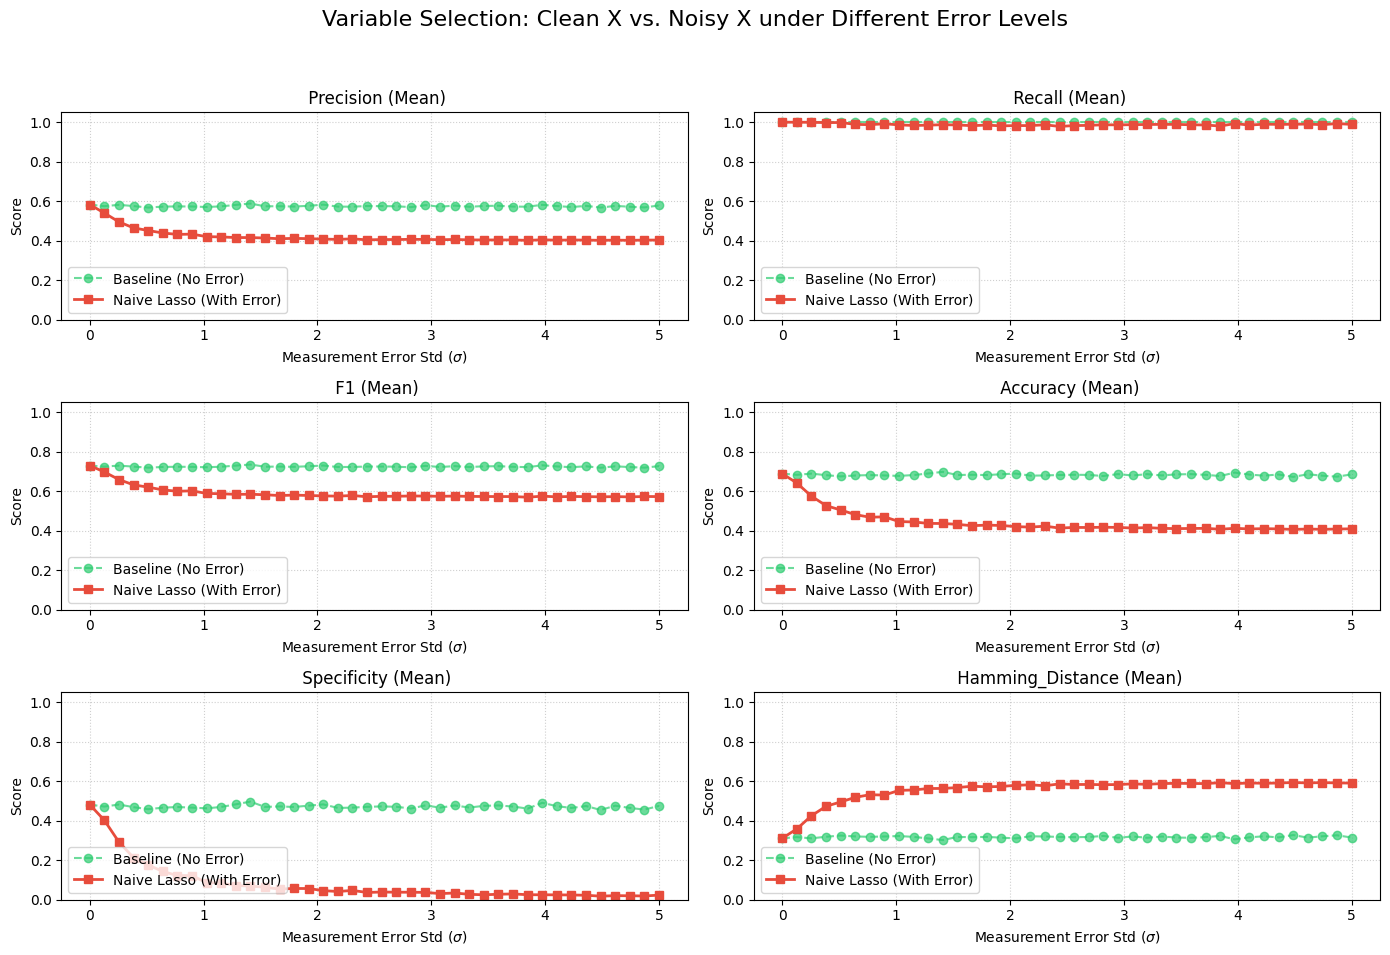

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.Lasso import LassoRegression as myLasso
from src.vs_evaluate import selection_accuracy

def run_contrast_simulation(n_simulations=500, seed=42):
    # 核心：在函数开始处固定种子
    np.random.seed(seed)

    n_samples, n_features = 1000, 10    # 固定样本量和特征数量
    n_signals = 4                       # 固定信号数量
    beta = np.zeros(n_features)         # 设定真实系数，前4个是信号，后6个是噪声
    beta[:n_signals] = np.array([1.5, -2.0, 0.2, -0.1])       # 信号强度
    true_indices = [i for i, b in enumerate(beta) if b != 0]  # 真实变量索引

    # 设定测量误差强度序列
    noise_levels = np.linspace(0, 5, 40) 
    metrics_list = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
    
    # 存储结构：results[metric][type] = [values_for_each_sigma]
    results = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}

    for sigma in noise_levels:
        temp_metrics = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}
        
        for _ in range(n_simulations):
            # 1. 生成基础数据 (DGP)
            X = np.random.randn(n_samples, n_features)
            # y 始终基于真实的 X 生成
            y = X @ beta + np.random.normal(0, 0.5, size=n_samples)

            # 2. 构造带误差的自变量
            X_error = X + np.random.normal(0, sigma, size=X.shape)

            # --- 实验组 A: 无测量误差 (Baseline) ---
            model_clean = myLasso(alpha=0.01)
            model_clean.fit(X, y)
            idx_clean = [i for i, c in enumerate(model_clean.coef_) if c != 0]
            res_clean = selection_accuracy(true_indices, idx_clean, n_features)

            # --- 实验组 B: 带测量误差 (Naive) ---
            model_noisy = myLasso(alpha=0.01)
            model_noisy.fit(X_error, y)
            idx_noisy = [i for i, c in enumerate(model_noisy.coef_) if c != 0]
            res_noisy = selection_accuracy(true_indices, idx_noisy, n_features)

            # 收集单次模拟数据
            for m in metrics_list:
                temp_metrics[m]['Clean'].append(res_clean[m])
                temp_metrics[m]['Noisy'].append(res_noisy[m])

        # 计算该 sigma 下的平均值
        for m in metrics_list:
            results[m]['Clean'].append(np.mean(temp_metrics[m]['Clean']))
            results[m]['Noisy'].append(np.mean(temp_metrics[m]['Noisy']))

    return noise_levels, results

# 执行模拟
noise_levels, final_data = run_contrast_simulation(500, seed=42)

# --- 2x2 比较图绘制 ---
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Variable Selection: Clean X vs. Noisy X under Different Error Levels', fontsize=16)

metrics = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
colors = {'Clean': '#2ecc71', 'Noisy': '#e74c3c'} # 绿色代表理想情况，红色代表误差情况

for i, ax in enumerate(axes.flat):
    m = metrics[i]
    
    # 绘制无误差 Baseline (理论上应接近水平线)
    ax.plot(noise_levels, final_data[m]['Clean'], 'o--', color=colors['Clean'], 
            label='Baseline (No Error)', alpha=0.7)
    
    # 绘制带误差曲线
    ax.plot(noise_levels, final_data[m]['Noisy'], 's-', color=colors['Noisy'], 
            label='Naive Lasso (With Error)', linewidth=2)
    
    ax.set_title(f' {m} (Mean)')
    ax.set_xlabel('Measurement Error Std ($\sigma$)')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower left')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 不同样本量的情况
+ 使用我的lasso代码，前 4 个是预设相关变量，参数设置为 1.5, -2.0, 0.2, -0.1，500 次模拟取评估指标的均值，随机种子 42（固定）
+ 测量误差强度为 1（已测试变化）
+ 样本量从 500 到 10000 变化共 40 个点（正在测试变化）
+ 正则化强度为 0.01，变量数量为 10（未测试变化）
+ 结果出来很快，2 分钟左右

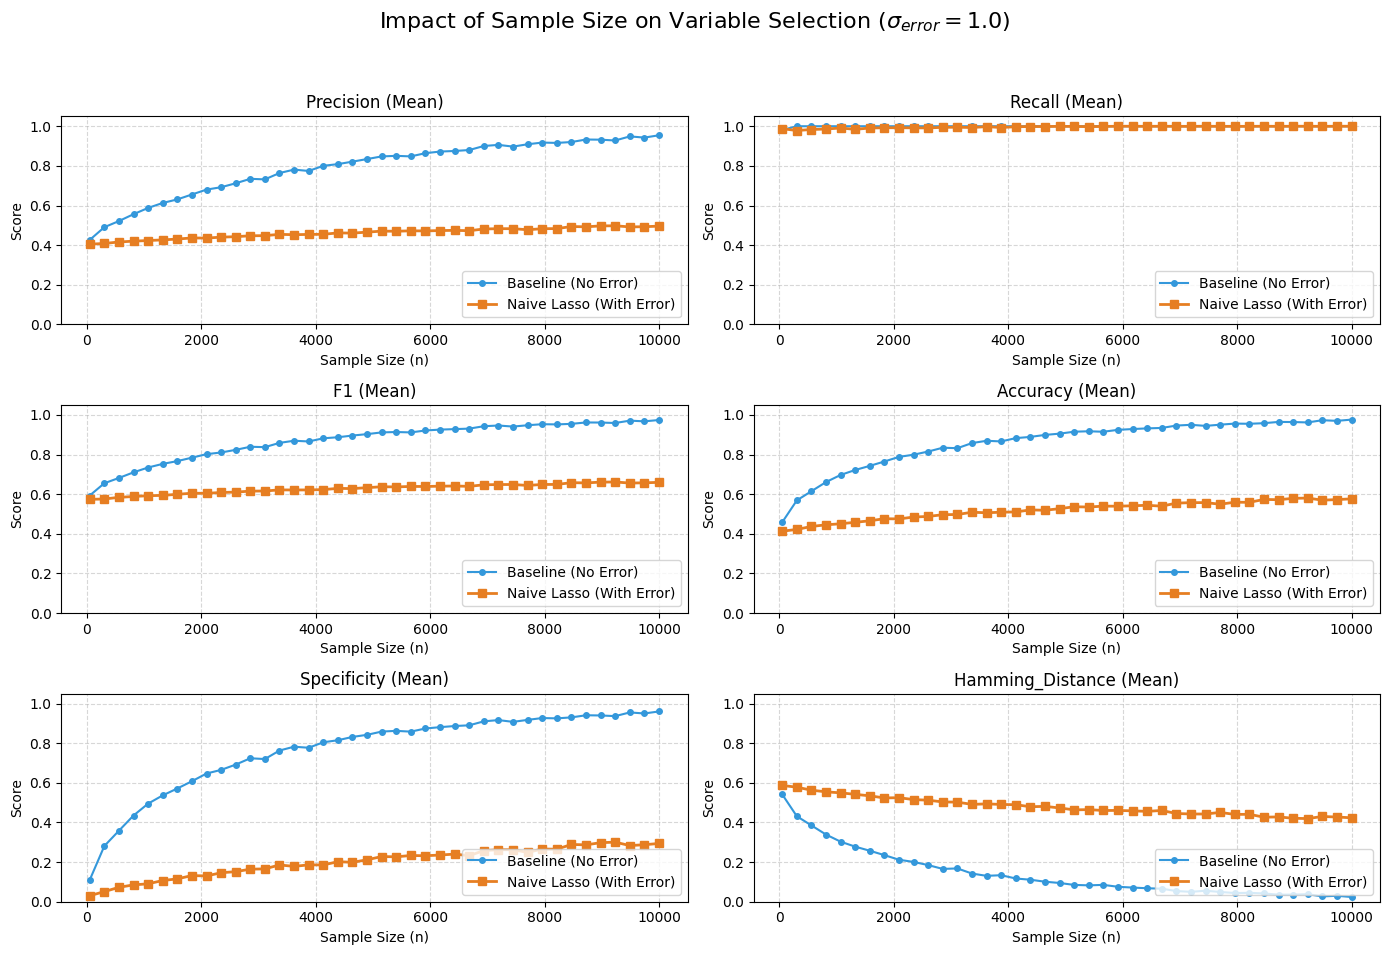

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from src.Lasso import LassoRegression as myLasso
from src.vs_evaluate import selection_accuracy

def run_samplesize_simulation(n_simulations=500, seed=42):
    # 核心：在函数开始处固定种子
    np.random.seed(seed)
    n_features = 10                 # 固定特征数量
    n_signals = 4                   # 固定信号数量
    beta = np.zeros(n_features)     # 设定真实系数，前4个是信号，后6个是噪声
    beta[:n_signals] = np.array([1.5, -2.0, 0.2, -0.1])       # 真实系数设定
    true_indices = [i for i, b in enumerate(beta) if b != 0]  # 真实变量索引

    # 设定样本量变化序列 (从 50 到 10000。注意：到 100000耗时较长)
    sample_sizes = np.linspace(50, 10000, 40).astype(int) 
    metrics_list = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
    
    # 固定测量误差强度
    FIXED_SIGMA = 1.0
    
    # 存储结构
    results = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}

    for n in sample_sizes:
        temp_metrics = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}
        
        for _ in range(n_simulations):
            # 1. 生成基础数据 (n 随循环变化)
            X = np.random.randn(n, n_features)
            y = X @ beta + np.random.normal(0, 0.5, size=n)

            # 2. 构造固定强度的测量误差
            X_error = X + np.random.normal(0, FIXED_SIGMA, size=X.shape)

            # --- 实验组 A: 无测量误差 (Baseline) ---
            model_clean = myLasso(alpha=0.01)
            model_clean.fit(X, y)
            idx_clean = [i for i, c in enumerate(model_clean.coef_) if c != 0]
            res_clean = selection_accuracy(true_indices, idx_clean, n_features)

            # --- 实验组 B: 带测量误差 (Naive) ---
            model_noisy = myLasso(alpha=0.01)
            model_noisy.fit(X_error, y)
            idx_noisy = [i for i, c in enumerate(model_noisy.coef_) if c != 0]
            res_noisy = selection_accuracy(true_indices, idx_noisy, n_features)

            for m in metrics_list:
                temp_metrics[m]['Clean'].append(res_clean[m])
                temp_metrics[m]['Noisy'].append(res_noisy[m])

        # 记录均值
        for m in metrics_list:
            results[m]['Clean'].append(np.mean(temp_metrics[m]['Clean']))
            results[m]['Noisy'].append(np.mean(temp_metrics[m]['Noisy']))

    return sample_sizes, results

# 执行模拟
sample_sizes, final_data = run_samplesize_simulation(500, seed=42)

# --- 3x2 可视化绘制 ---
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle(f'Impact of Sample Size on Variable Selection ($\sigma_{{error}}={1.0}$)', fontsize=16)

metrics = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
colors = {'Clean': '#3498db', 'Noisy': '#e67e22'} # 蓝色代表理想，橙色代表有误差

for i, ax in enumerate(axes.flat):
    m = metrics[i]
    
    # 无误差组
    ax.plot(sample_sizes, final_data[m]['Clean'], 'o-', color=colors['Clean'], 
            label='Baseline (No Error)', markersize=4)
    
    # 有误差组
    ax.plot(sample_sizes, final_data[m]['Noisy'], 's-', color=colors['Noisy'], 
            label='Naive Lasso (With Error)', linewidth=2)
    
    ax.set_title(f'{m} (Mean)')
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 不同正则化强度
+ 使用我的lasso代码，前 4 个是预设相关变量，参数设置为 1.5, -2.0, 0.2, -0.1，500 次模拟取评估指标的均值，随机种子 42（固定）
+ 样本量为 1000，测量误差强度为 1（已测试变化）
+ 正则化强度为对数轴 10^-4 到 10^1 共 50 个点（正在测试变化）
+ 变量数量为 10（未测试变化）
+ 结果出来很快，1 分钟左右

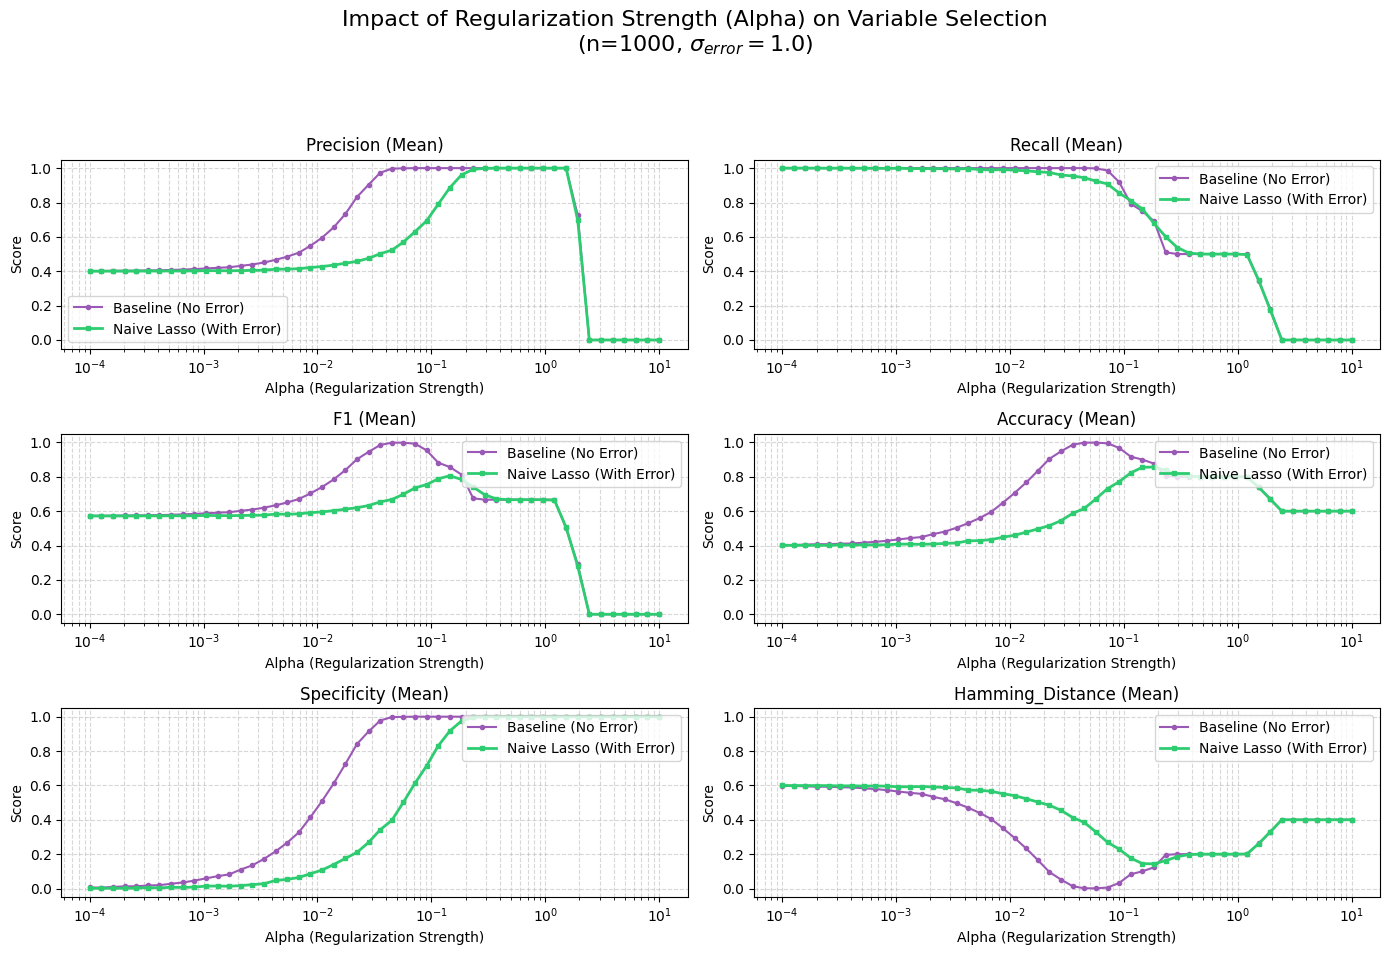

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from src.Lasso import LassoRegression as myLasso
from src.vs_evaluate import selection_accuracy

def run_alpha_simulation(n_simulations=500, seed=42):
    # 1. 固定种子和参数
    np.random.seed(seed)
    n_samples = 1000
    fixed_sigma = 1.0
    n_features = 10
    n_signals = 4

    # 设定 alpha 序列 (对数空间更科学)
    alphas = np.logspace(-4, 1, 50) 
    metrics_list = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']

    # 存储结构
    results = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}
    
    beta = np.zeros(n_features)
    beta[:n_signals] = np.array([1.5, -2.0, 0.2, -0.1])
    true_indices = [i for i, b in enumerate(beta) if b != 0]

    # 预生成数据的基础部分以提高效率
    # 注意：为了严谨，每次模拟仍需独立的噪声
    for a in alphas:
        temp_metrics = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}
        
        for _ in range(n_simulations):
            # 生成数据
            X = np.random.randn(n_samples, n_features)
            y = X @ beta + np.random.normal(0, 0.5, size=n_samples)
            X_error = X + np.random.normal(0, fixed_sigma, size=X.shape)

            # --- 实验组 A: Clean ---
            model_clean = myLasso(alpha=a)
            model_clean.fit(X, y)
            idx_clean = [i for i, c in enumerate(model_clean.coef_) if c != 0]
            res_clean = selection_accuracy(true_indices, idx_clean, n_features)

            # --- 实验组 B: Noisy ---
            model_noisy = myLasso(alpha=a)
            model_noisy.fit(X_error, y)
            idx_noisy = [i for i, c in enumerate(model_noisy.coef_) if c != 0]
            res_noisy = selection_accuracy(true_indices, idx_noisy, n_features)

            for m in metrics_list:
                temp_metrics[m]['Clean'].append(res_clean[m])
                temp_metrics[m]['Noisy'].append(res_noisy[m])

        # 记录该 alpha 下的平均值
        for m in metrics_list:
            results[m]['Clean'].append(np.mean(temp_metrics[m]['Clean']))
            results[m]['Noisy'].append(np.mean(temp_metrics[m]['Noisy']))

    return alphas, results

# 执行模拟
alphas_seq, plot_data = run_alpha_simulation(500, seed=42)

# --- 3x2 可视化绘制 ---
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle(f'Impact of Regularization Strength (Alpha) on Variable Selection\n(n={1000}, $\sigma_{{error}}={1.0}$)', fontsize=16)

metrics = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
colors = {'Clean': '#9b59b6', 'Noisy': '#2ecc71'} # 紫色代表理想，绿色代表有误差

for i, ax in enumerate(axes.flat):
    m = metrics[i]
    # 无误差组
    ax.plot(alphas_seq, plot_data[m]['Clean'], 'o-', color=colors['Clean'], 
            label='Baseline (No Error)', markersize=3)
    # 有误差组
    ax.plot(alphas_seq, plot_data[m]['Noisy'], 's-', color=colors['Noisy'], 
            label='Naive Lasso (With Error)', linewidth=2, markersize=3)
    
    ax.set_title(f'{m} (Mean)')
    ax.set_xlabel('Alpha (Regularization Strength)')
    ax.set_ylabel('Score')
    ax.set_xscale('log') # 因为 alpha 是跨数量级的，对数坐标更易观察
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='lower left' if m == 'Precision' else 'upper right')
    ax.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# 不同变量数量
+ 使用我的lasso代码，前 4 个是预设相关变量，参数设置为 1.5, -2.0, 0.2, -0.1，500 次模拟取评估指标的均值，随机种子 42（固定）
+ 样本量为 1000，测量误差强度为 1，正则化强度为 0.1（已测试变化）
+ 变量数量从 10 到 100 变化共 20 个点（正在测试变化）
+ 结果出来很快，3 分钟左右（变量数从 10 到 2000 变化共 20 个点，模拟 2 次，3 分钟左右；模拟 50 次，110 分钟左右）
+ **变量数量从 5 到 2000 变化共 100 个点，结果跑了 5 个小时，没跑出来**

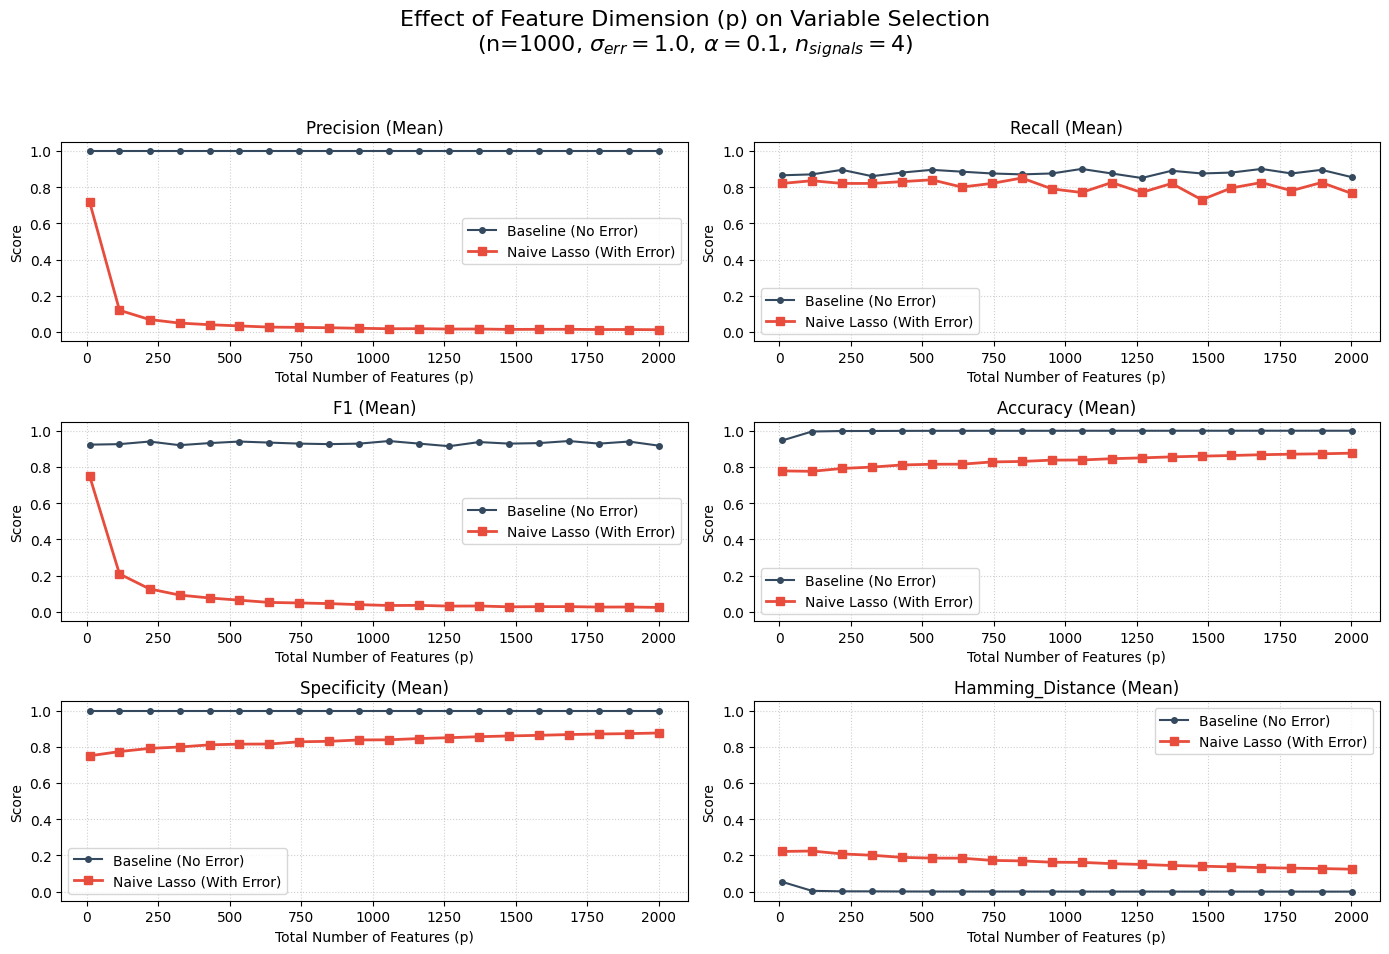

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from src.Lasso import LassoRegression as myLasso
from src.vs_evaluate import selection_accuracy

def run_dimension_simulation(n_simulations=500, seed=42):
    np.random.seed(seed)
    
    # 固定参数
    n_samples = 1000
    fixed_sigma = 1.0
    fixed_alpha = 0.1
    n_signals = 4
    
    # 设定特征数变化序列 (从 10 到 1001)
    feature_counts = np.linspace(10, 2001, 20).astype(int)
    metrics_list = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
    
    results = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}
    
    # 真实的 Beta 逻辑：前 4 个固定
    base_beta_values = np.array([1.5, -2.0, 0.2, -0.1])

    for p in feature_counts:
        temp_metrics = {m: {'Clean': [], 'Noisy': []} for m in metrics_list}
        
        # 构造当前维度下的 beta
        beta = np.zeros(p)
        beta[:n_signals] = base_beta_values
        true_indices = list(range(n_signals))
        
        for _ in range(n_simulations):
            X = np.random.randn(n_samples, p)
            y = X @ beta + np.random.normal(0, 0.5, size=n_samples)
            X_error = X + np.random.normal(0, fixed_sigma, size=X.shape)

            # --- 实验组 A: 无测量误差 (Baseline) ---
            model_c = myLasso(alpha=fixed_alpha)
            model_c.fit(X, y)
            idx_c = [i for i, c in enumerate(model_c.coef_) if c != 0]
            res_c = selection_accuracy(true_indices, idx_c, p)

            # --- 实验组 B: 带测量误差 (Naive) ---
            model_n = myLasso(alpha=fixed_alpha)
            model_n.fit(X_error, y)
            idx_n = [i for i, c in enumerate(model_n.coef_) if c != 0]
            res_n = selection_accuracy(true_indices, idx_n, p)

            for m in metrics_list:
                temp_metrics[m]['Clean'].append(res_c[m])
                temp_metrics[m]['Noisy'].append(res_n[m])

        for m in metrics_list:
            results[m]['Clean'].append(np.mean(temp_metrics[m]['Clean']))
            results[m]['Noisy'].append(np.mean(temp_metrics[m]['Noisy']))

    return feature_counts, results

# 执行模拟
p_seq, plot_data = run_dimension_simulation(50, seed=42)

# --- 可视化 ---
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle(f'Effect of Feature Dimension (p) on Variable Selection\n(n=1000, $\sigma_{{err}}=1.0$, $\\alpha=0.1$, $n_{{signals}}=4$)', fontsize=16)

metrics = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity', 'Hamming_Distance']
colors = {'Clean': '#34495e', 'Noisy': '#e74c3c'}

for i, ax in enumerate(axes.flat):
    m = metrics[i]
    # 无误差组
    ax.plot(p_seq, plot_data[m]['Clean'], 'o-', color=colors['Clean'], label='Baseline (No Error)', markersize=4)
    # 有误差组
    ax.plot(p_seq, plot_data[m]['Noisy'], 's-', color=colors['Noisy'], label='Naive Lasso (With Error)', linewidth=2)
    
    ax.set_title(f'{m} (Mean)')
    ax.set_xlabel('Total Number of Features (p)')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()